# 02 - Main ESN Experiments

Runs the definitive RQ1 to RQ3 experiments using the locked reservoir from Notebook 01. See Methodology Sections 3.2 to 3.4, Results Sections 4.2 to 4.4, and Appendix E.

## 0. Imports

Loads the libraries used by the definitive experimental run.

In [2]:

from pathlib import Path
import gc
import hashlib
import json
import os
import platform
import random
import sys
import time

import joblib
import librosa
import matplotlib.pyplot as plt
import numpy as np
import reservoirpy as rpy

from reservoirpy.nodes import Reservoir
from scipy.stats import binomtest, chi2
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rpy.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.environ["RESERVOIRPY_VERBOSITY"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")


Device: cuda
Python: 3.11.15
Platform: Linux-6.18.7-76061807-generic-x86_64-with-glibc2.39


## 1. Configuration

Loads the locked Notebook 01 manifest and defines the unchanged feature, reservoir, Ridge and neural settings.

In [3]:

def find_project_root() -> Path:
    """Find the repository root from the data/nsynth folder."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "data" / "nsynth").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find data/nsynth. Start Jupyter inside the repository."
    )


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data" / "nsynth"

TRAIN_DIR = DATA_ROOT / "nsynth-train"
VALID_DIR = DATA_ROOT / "nsynth-valid"
TEST_DIR = DATA_ROOT / "nsynth-test"

CACHE_ROOT = PROJECT_ROOT / "cache_final"
SELECTION_DIR = PROJECT_ROOT / "results_sweep_final"
SELECTION_MANIFEST_PATH = (
    SELECTION_DIR / "selected_reservoir_config.json"
)

CACHE_ROOT.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# Acoustic front end
# Must match notebook 01 exactly.
# ---------------------------------------------------------------------
SR = 16_000
N_MELS = 64
N_FFT = 1_024
HOP_LENGTH = 512
MAX_T = 125
USE_DELTAS = True
FEAT_DIM = N_MELS * (3 if USE_DELTAS else 1)
SCALER_N_EXAMPLES = 3_000

FEATURE_CFG = {
    "sr": SR,
    "n_mels": N_MELS,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "max_t": MAX_T,
    "use_deltas": USE_DELTAS,
    "delta_after_length_fix": True,
}

# ---------------------------------------------------------------------
# NSynth class scheme
# ---------------------------------------------------------------------
FAMILY_NAMES = [
    "bass", "brass", "flute", "guitar", "keyboard",
    "mallet", "organ", "reed", "string", "vocal",
]
N_CLASSES = len(FAMILY_NAMES)
SYNTH_LEAD_IDX = 9
FAMILY_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4,
              5: 5, 6: 6, 7: 7, 8: 8, 10: 9}

# ---------------------------------------------------------------------
# Load and validate the locked reservoir selection
# ---------------------------------------------------------------------
if not SELECTION_MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "Missing locked reservoir manifest. Run notebook 01 first: "
        f"{SELECTION_MANIFEST_PATH}"
    )

with open(SELECTION_MANIFEST_PATH) as f:
    SELECTION_MANIFEST = json.load(f)

if SELECTION_MANIFEST.get("selection_status") != "locked":
    raise RuntimeError("Reservoir-selection manifest is not locked.")

if SELECTION_MANIFEST.get("feature_cfg") != FEATURE_CFG:
    raise RuntimeError(
        "Feature configuration differs from notebook 01. "
        "Do not continue with incompatible caches."
    )

if int(SELECTION_MANIFEST.get("reservoir_seed")) != SEED:
    raise RuntimeError(
        "Reservoir seed differs from the locked selection manifest."
    )

RESERVOIR_CFG = dict(SELECTION_MANIFEST["reservoir_cfg"])
RESERVOIR_UNITS = int(RESERVOIR_CFG["units"])

# ---------------------------------------------------------------------
# Cache controls
# ---------------------------------------------------------------------
FORCE_REBUILD_MEL_CACHE = False
FORCE_REBUILD_STATE_CACHE = False
MEL_CACHE_DTYPE = np.float32
STATE_CACHE_DTYPE = np.float16

# ---------------------------------------------------------------------
# Matched Ridge comparison
# Exact grid and solver settings used by notebook 01.
# ---------------------------------------------------------------------
RIDGE_TRAIN_N = None
RIDGE_ALPHAS = list(
    SELECTION_MANIFEST["search_design"]["ridge_alphas"]
)
RIDGE_CLASS_WEIGHT = "balanced"
RIDGE_SOLVER = SELECTION_MANIFEST["search_design"]["ridge_solver"]
RIDGE_TOL = float(
    SELECTION_MANIFEST["search_design"]["ridge_tol"]
)
RIDGE_MAX_ITER = int(
    SELECTION_MANIFEST["search_design"]["ridge_max_iter"]
)
RIDGE_TIE_ATOL = 1e-12

# ---------------------------------------------------------------------
# Matched neural readouts
# ---------------------------------------------------------------------
BATCH_SIZE = 512
NUM_WORKERS = 12
HIDDEN_DIM = 128
DROPOUT = 0.30
LR = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 60
PATIENCE = 10
READOUT_SEED = 0
VALIDATION_METRIC = "macro_f1"

# ---------------------------------------------------------------------
# RQ3 and final-run controls
# ---------------------------------------------------------------------
ATTACK_FRAMES = 20
FINAL_RUN = True
ROBUSTNESS_SEEDS = (0, 1, 2, 3, 4)
RUN_SEED_ROBUSTNESS = FINAL_RUN
RUN_ATTENTION_SEED_ANALYSIS = FINAL_RUN
RUN_READOUT_ABLATION = FINAL_RUN
RUN_INPUT_ABLATION = FINAL_RUN
ABLATION_SEED = READOUT_SEED
KEEP_MASKED_STATE_CACHES = False

# Optional debug limits. Keep None for definitive runs.
N_TRAIN_LIMIT = None
N_VALID_LIMIT = None
N_TEST_LIMIT = None


def stable_hash(obj) -> str:
    txt = json.dumps(obj, sort_keys=True, default=str)
    return hashlib.sha1(txt.encode("utf-8")).hexdigest()[:10]


def ordered_hash(values) -> str:
    payload = json.dumps(list(values), separators=(",", ":"))
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()


FEATURE_TAG = stable_hash(FEATURE_CFG)
if FEATURE_TAG != SELECTION_MANIFEST["feature_tag"]:
    raise RuntimeError("Feature tag does not match notebook 01.")

SCALER_CFG = {
    "feature_tag": FEATURE_TAG,
    "scaler_n_examples": SCALER_N_EXAMPLES,
    "seed": SEED,
}
SCALER_TAG = stable_hash(SCALER_CFG)
if SCALER_TAG != SELECTION_MANIFEST["scaler_tag"]:
    raise RuntimeError("Feature-scaler tag does not match notebook 01.")

STATE_TAG = stable_hash(
    {
        "feature_tag": FEATURE_TAG,
        "scaler_tag": SCALER_TAG,
        "reservoir_cfg": RESERVOIR_CFG,
        "seed": SEED,
        "state_cache_dtype": str(np.dtype(STATE_CACHE_DTYPE)),
    }
)

RUN_CFG = {
    "feature_tag": FEATURE_TAG,
    "scaler_tag": SCALER_TAG,
    "state_tag": STATE_TAG,
    "reservoir_cfg": RESERVOIR_CFG,
    "ridge_alphas": RIDGE_ALPHAS,
    "ridge_solver": RIDGE_SOLVER,
    "ridge_tol": RIDGE_TOL,
    "ridge_max_iter": RIDGE_MAX_ITER,
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": N_EPOCHS,
    "patience": PATIENCE,
    "validation_metric": VALIDATION_METRIC,
    "readout_seeds": ROBUSTNESS_SEEDS,
}
RUN_TAG = stable_hash(RUN_CFG)

MEL_CACHE_DIR = CACHE_ROOT / f"mel_{FEATURE_TAG}"
STATE_CACHE_DIR = CACHE_ROOT / f"states_{STATE_TAG}"
RESULTS_DIR = PROJECT_ROOT / "results_final" / f"run_{RUN_TAG}"

MEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
STATE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Locked reservoir: {RESERVOIR_CFG}")
print(f"Feature cache:    {MEL_CACHE_DIR}")
print(f"State cache:      {STATE_CACHE_DIR}")
print(f"Results:          {RESULTS_DIR}")
print(f"Run tag:          {RUN_TAG}")
print(f"Ridge grid:       {RIDGE_ALPHAS}")
print(f"Neural budget:    {N_EPOCHS} epochs, patience={PATIENCE}")


Locked reservoir: {'units': 1000, 'sr': 0.99, 'lr': 0.05, 'input_scaling': 0.2, 'rc_connectivity': 0.1}
Feature cache:    /home/olliechandler/ESN-NSYNTH/cache_final/mel_8cfbd6d555
State cache:      /home/olliechandler/ESN-NSYNTH/cache_final/states_242d8f6835
Results:          /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b
Run tag:          35d8eed08b
Ridge grid:       [1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]
Neural budget:    60 epochs, patience=10


## 2. NSynth metadata

Uses the official train, validation and test splits and removes the synth-lead family. See Methodology Section 3.1.1.

In [4]:
def load_metadata(split_dir: Path) -> dict:
    path = split_dir / "examples.json"
    if not path.exists():
        raise FileNotFoundError(f"Missing metadata file: {path}")
    with open(path, "r") as f:
        return json.load(f)


def keep_key(key: str, meta: dict) -> bool:
    return meta[key]["instrument_family"] != SYNTH_LEAD_IDX


def label_of(key: str, meta: dict) -> int:
    return FAMILY_MAP[meta[key]["instrument_family"]]


def split_keys(meta: dict, limit=None):
    keys = [k for k in meta.keys() if keep_key(k, meta)]
    keys = sorted(keys)
    if limit is not None:
        keys = keys[:limit]
    return keys


train_meta = load_metadata(TRAIN_DIR)
valid_meta = load_metadata(VALID_DIR)
test_meta  = load_metadata(TEST_DIR)

train_keys = split_keys(train_meta, N_TRAIN_LIMIT)
valid_keys = split_keys(valid_meta, N_VALID_LIMIT)
test_keys  = split_keys(test_meta,  N_TEST_LIMIT)

print(f"Train: {len(train_keys):,}")
print(f"Valid: {len(valid_keys):,}")
print(f"Test:  {len(test_keys):,}")

train_labels_preview = np.array([label_of(k, train_meta) for k in train_keys])
counts = np.bincount(train_labels_preview, minlength=N_CLASSES)
print("\nTraining class distribution:")
for name, count in zip(FAMILY_NAMES, counts):
    print(f"  {name:10s} {count:,}")


Train: 283,704
Valid: 12,678
Test:  4,096

Training class distribution:
  bass       65,474
  brass      12,675
  flute      8,773
  guitar     32,690
  keyboard   51,821
  mallet     34,201
  organ      34,477
  reed       13,911
  string     19,474
  vocal      10,208


## 3. Log-mel features

Defines the 64-band log-mel, delta and delta-delta representation. See Methodology Section 3.1.2.

In [5]:

def audio_path(split_dir: Path, key: str) -> Path:
    return split_dir / "audio" / f"{key}.wav"


def load_audio(split_dir: Path, key: str) -> np.ndarray:
    path = audio_path(split_dir, key)
    if not path.exists():
        raise FileNotFoundError(f"Missing audio file: {path}")
    audio, _ = librosa.load(path, sr=SR, mono=True)
    return audio


def fix_static_length(
    static: np.ndarray,
    max_t: int = MAX_T,
) -> np.ndarray:
    # static shape: (time, mel)
    if static.shape[0] >= max_t:
        return static[:max_t]
    pad = np.zeros(
        (max_t - static.shape[0], static.shape[1]),
        dtype=static.dtype,
    )
    return np.vstack([static, pad])


def extract_mel_feature(
    split_dir: Path,
    key: str,
) -> np.ndarray:
    audio = load_audio(split_dir, key)
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    static = librosa.power_to_db(
        mel, ref=np.max
    ).T.astype(np.float32)
    static = fix_static_length(static)

    if not USE_DELTAS:
        return static

    # Deltas are calculated after static length has been fixed.
    # The masking pipeline uses the identical 125-frame context.
    d1 = librosa.feature.delta(static.T, order=1).T
    d2 = librosa.feature.delta(static.T, order=2).T
    return np.concatenate(
        [static, d1, d2], axis=1
    ).astype(np.float32)


## 4. Acoustic feature caches

Builds or loads the fixed NSynth feature caches used by every experiment.

In [6]:

def mel_cache_paths(split_name: str):
    return (
        MEL_CACHE_DIR / f"X_{split_name}.npy",
        MEL_CACHE_DIR / f"y_{split_name}.npy",
        MEL_CACHE_DIR / f"keys_{split_name}.json",
        MEL_CACHE_DIR / f"manifest_{split_name}.json",
    )


def npy_cache_valid(
    path: Path,
    expected_shape: tuple,
    expected_dtype,
) -> bool:
    if not path.exists():
        return False
    try:
        arr = np.load(path, mmap_mode="r")
        valid = (
            arr.shape == expected_shape
            and arr.dtype == np.dtype(expected_dtype)
        )
        del arr
        return valid
    except Exception:
        return False


def cache_mel_split(
    split_name: str,
    split_dir: Path,
    keys: list,
    metadata: dict,
):
    X_path, y_path, keys_path, manifest_path = (
        mel_cache_paths(split_name)
    )
    expected_key_hash = ordered_hash(keys)
    expected_labels = [label_of(k, metadata) for k in keys]
    expected_label_hash = ordered_hash(expected_labels)

    valid = (
        npy_cache_valid(
            X_path,
            (len(keys), MAX_T, FEAT_DIM),
            MEL_CACHE_DTYPE,
        )
        and npy_cache_valid(
            y_path, (len(keys),), np.int64
        )
        and keys_path.exists()
        and manifest_path.exists()
    )

    if valid and not FORCE_REBUILD_MEL_CACHE:
        with open(keys_path) as f:
            cached_keys = json.load(f)
        with open(manifest_path) as f:
            manifest = json.load(f)

        valid = (
            cached_keys == keys
            and manifest.get("feature_cfg") == FEATURE_CFG
            and manifest.get("ordered_key_hash")
            == expected_key_hash
            and manifest.get("ordered_label_hash")
            == expected_label_hash
        )

    if valid and not FORCE_REBUILD_MEL_CACHE:
        print(
            f"Using existing feature cache for "
            f"{split_name}: {X_path}"
        )
        return X_path, y_path, keys_path

    print(f"Building feature cache for {split_name}...")
    X = np.lib.format.open_memmap(
        X_path,
        mode="w+",
        dtype=MEL_CACHE_DTYPE,
        shape=(len(keys), MAX_T, FEAT_DIM),
    )
    y = np.lib.format.open_memmap(
        y_path,
        mode="w+",
        dtype=np.int64,
        shape=(len(keys),),
    )

    started = time.time()
    for i, key in enumerate(keys):
        X[i] = extract_mel_feature(split_dir, key)
        y[i] = label_of(key, metadata)

        if (i + 1) % 5_000 == 0 or i + 1 == len(keys):
            elapsed = time.time() - started
            rate = (i + 1) / max(elapsed, 1e-9)
            print(
                f"  {split_name:5s} {i+1:,}/{len(keys):,} "
                f"| {rate:.1f} examples/s"
            )
            X.flush()
            y.flush()

    with open(keys_path, "w") as f:
        json.dump(keys, f)
    with open(manifest_path, "w") as f:
        json.dump(
            {
                "split": split_name,
                "feature_cfg": FEATURE_CFG,
                "feature_tag": FEATURE_TAG,
                "ordered_key_hash": expected_key_hash,
                "ordered_label_hash": expected_label_hash,
                "n_examples": len(keys),
            },
            f,
            indent=2,
        )

    X.flush()
    y.flush()
    del X, y
    gc.collect()
    return X_path, y_path, keys_path


train_mel_X, train_y_path, train_keys_path = cache_mel_split(
    "train", TRAIN_DIR, train_keys, train_meta
)
valid_mel_X, valid_y_path, valid_keys_path = cache_mel_split(
    "valid", VALID_DIR, valid_keys, valid_meta
)
test_mel_X, test_y_path, test_keys_path = cache_mel_split(
    "test", TEST_DIR, test_keys, test_meta
)


Using existing feature cache for train: /home/olliechandler/ESN-NSYNTH/cache_final/mel_8cfbd6d555/X_train.npy
Using existing feature cache for valid: /home/olliechandler/ESN-NSYNTH/cache_final/mel_8cfbd6d555/X_valid.npy
Building feature cache for test...
  test  4,096/4,096 | 491.4 examples/s


## 5. Cache check

Checks the cached acoustic representation before modelling.

Full cached feature shape: (125, 192)
Static log-mel range:      -80.00 to 0.00 dB
First-delta range:         -6.37 to 4.52
Second-delta range:        -3.81 to 2.76


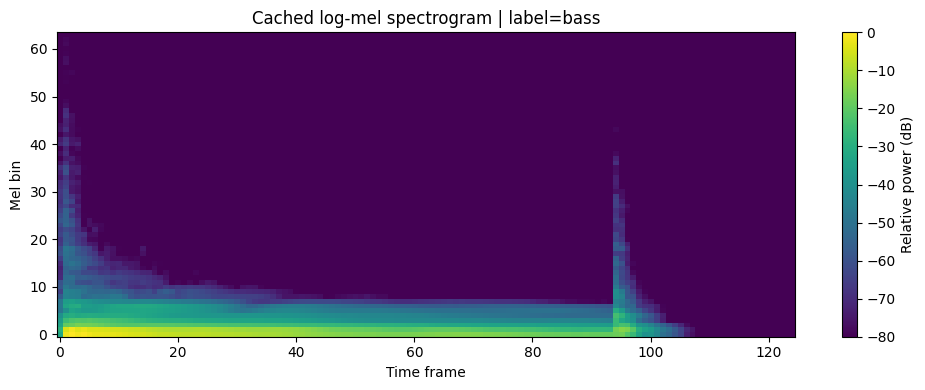

5682

In [7]:
X_train_mel = np.load(train_mel_X, mmap_mode="r")
y_train = np.load(train_y_path, mmap_mode="r")

i = 0
sample = np.asarray(X_train_mel[i], dtype=np.float32)

assert sample.shape == (MAX_T, FEAT_DIM), (
    f"Unexpected cached feature shape: {sample.shape}; "
    f"expected {(MAX_T, FEAT_DIM)}"
)
assert np.isfinite(sample).all(), "Cached features contain NaN or infinite values"

static_mel = sample[:, :N_MELS]
print(f"Full cached feature shape: {sample.shape}")
print(f"Static log-mel range:      {static_mel.min():.2f} to {static_mel.max():.2f} dB")

if USE_DELTAS:
    delta = sample[:, N_MELS:2 * N_MELS]
    delta2 = sample[:, 2 * N_MELS:3 * N_MELS]
    print(f"First-delta range:         {delta.min():.2f} to {delta.max():.2f}")
    print(f"Second-delta range:        {delta2.min():.2f} to {delta2.max():.2f}")

plt.figure(figsize=(10, 4))
plt.imshow(
    static_mel.T,
    origin="lower",
    aspect="auto",
    vmin=-80,
    vmax=0,
)
plt.title(
    f"Cached log-mel spectrogram | "
    f"label={FAMILY_NAMES[int(y_train[i])]}"
)
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.colorbar(label="Relative power (dB)")
plt.tight_layout()
plt.show()

del X_train_mel, y_train, sample, static_mel
if USE_DELTAS:
    del delta, delta2
gc.collect()


## 6. Feature scaler

Fits or loads the training-only feature scaler used by all downstream models.

In [8]:
FEATURE_SCALER_PATH = MEL_CACHE_DIR / f"feature_scaler_{SCALER_TAG}.joblib"


def fit_or_load_feature_scaler():
    if FEATURE_SCALER_PATH.exists() and not FORCE_REBUILD_MEL_CACHE:
        print(f"Loading feature scaler: {FEATURE_SCALER_PATH}")
        return joblib.load(FEATURE_SCALER_PATH)

    print("Fitting feature scaler from training mel cache...")
    X = np.load(train_mel_X, mmap_mode="r")
    rng = np.random.default_rng(SEED)
    n = min(SCALER_N_EXAMPLES, len(X))
    idx = rng.choice(len(X), size=n, replace=False)

    scaler = StandardScaler()
    for start in range(0, len(idx), 64):
        batch_idx = idx[start:start + 64]
        frames = np.asarray(X[batch_idx], dtype=np.float32).reshape(-1, FEAT_DIM)
        scaler.partial_fit(frames)

    joblib.dump(scaler, FEATURE_SCALER_PATH)
    print(f"Saved feature scaler: {FEATURE_SCALER_PATH}")

    del X
    gc.collect()
    return scaler


feature_scaler = fit_or_load_feature_scaler()


Loading feature scaler: /home/olliechandler/ESN-NSYNTH/cache_final/mel_8cfbd6d555/feature_scaler_2e0a669124.joblib


## 7. RQ1 - acoustic Ridge

Evaluates pooled acoustic features with the Ridge procedure defined in Methodology Section 3.2.

In [9]:

def load_labels(y_path: Path) -> np.ndarray:
    return np.asarray(
        np.load(y_path, mmap_mode="r"),
        dtype=np.int64,
    )


def choose_train_indices(n: int, limit):
    if limit is None or limit >= n:
        return np.arange(n, dtype=np.int64)
    rng = np.random.default_rng(SEED)
    return np.sort(
        rng.choice(n, size=limit, replace=False)
    )


def summarise_sequence_cache(
    X_path: Path,
    indices=None,
    scaler=None,
    chunk_size: int = 1_024,
) -> np.ndarray:
    X = np.load(X_path, mmap_mode="r")
    if indices is None:
        indices = np.arange(len(X), dtype=np.int64)
    else:
        indices = np.asarray(indices, dtype=np.int64)

    feat_dim = X.shape[-1]
    out = np.empty(
        (len(indices), feat_dim * 3),
        dtype=np.float32,
    )

    for start in range(0, len(indices), chunk_size):
        end = min(start + chunk_size, len(indices))
        batch_indices = indices[start:end]
        A = np.asarray(
            X[batch_indices], dtype=np.float32
        )

        if scaler is not None:
            A = scaler.transform(
                A.reshape(-1, feat_dim)
            ).reshape(A.shape)

        out[start:end] = np.concatenate(
            [
                A.mean(axis=1),
                A.max(axis=1),
                A[:, -1, :],
            ],
            axis=1,
        )

    del X
    gc.collect()
    return out


def classification_metrics(
    labels: np.ndarray,
    predictions: np.ndarray,
) -> dict:
    return {
        "acc": float(
            accuracy_score(labels, predictions)
        ),
        "macro_f1": float(
            f1_score(
                labels,
                predictions,
                average="macro",
            )
        ),
        "balanced_acc": float(
            balanced_accuracy_score(
                labels, predictions
            )
        ),
    }


def select_ridge_candidate(rows: list[dict]) -> dict:
    best_score = max(
        row[VALIDATION_METRIC] for row in rows
    )
    tied = [
        row for row in rows
        if np.isclose(
            row[VALIDATION_METRIC],
            best_score,
            rtol=0.0,
            atol=RIDGE_TIE_ATOL,
        )
    ]
    # Prefer stronger regularisation if predictions tie.
    return max(tied, key=lambda row: row["alpha"])


def fit_ridge_readout(
    Xtr,
    ytr,
    Xva,
    yva,
    Xte,
    yte,
    tag: str,
):
    summary_scaler = StandardScaler().fit(Xtr)
    Xtr_s = summary_scaler.transform(Xtr)
    Xva_s = summary_scaler.transform(Xva)
    Xte_s = summary_scaler.transform(Xte)

    tuning_rows = []
    models = {}

    for alpha in RIDGE_ALPHAS:
        classifier = RidgeClassifier(
            alpha=alpha,
            class_weight=RIDGE_CLASS_WEIGHT,
            solver=RIDGE_SOLVER,
            tol=RIDGE_TOL,
            max_iter=RIDGE_MAX_ITER,
        )
        classifier.fit(Xtr_s, ytr)
        validation_prediction = classifier.predict(Xva_s)
        validation_metrics = classification_metrics(
            yva, validation_prediction
        )
        tuning_rows.append(
            {
                "alpha": float(alpha),
                **validation_metrics,
                "n_iter": (
                    None
                    if classifier.n_iter_ is None
                    else np.asarray(
                        classifier.n_iter_
                    ).tolist()
                ),
            }
        )
        models[float(alpha)] = classifier

    selected = select_ridge_candidate(tuning_rows)
    selected_alpha = float(selected["alpha"])
    selected_model = models[selected_alpha]

    test_predictions = selected_model.predict(Xte_s)
    test_metrics = classification_metrics(
        yte, test_predictions
    )

    print(tag)
    print(f"  selected alpha: {selected_alpha:.1e}")
    print(
        f"  valid {VALIDATION_METRIC}: "
        f"{selected[VALIDATION_METRIC]*100:.2f}%"
    )
    print(
        f"  test accuracy:   "
        f"{test_metrics['acc']*100:.2f}%"
    )
    print(
        f"  test macro F1:   "
        f"{test_metrics['macro_f1']*100:.2f}%"
    )
    print(
        f"  test balanced:   "
        f"{test_metrics['balanced_acc']*100:.2f}%"
    )

    if selected_alpha in (
        min(RIDGE_ALPHAS),
        max(RIDGE_ALPHAS),
    ):
        print(
            "  WARNING: selected alpha is still on "
            "the expanded search boundary."
        )

    return {
        "tag": tag,
        "alpha": selected_alpha,
        "validation": {
            key: float(selected[key])
            for key in (
                "acc",
                "macro_f1",
                "balanced_acc",
            )
        },
        "selection_metric": VALIDATION_METRIC,
        "selection_score": float(
            selected[VALIDATION_METRIC]
        ),
        "test": test_metrics,
        "tuning_curve": tuning_rows,
        "preds": test_predictions,
    }


y_train = load_labels(train_y_path)
y_valid = load_labels(valid_y_path)
y_test = load_labels(test_y_path)

ridge_train_idx = choose_train_indices(
    len(y_train), RIDGE_TRAIN_N
)

Xtr_mel = summarise_sequence_cache(
    train_mel_X,
    ridge_train_idx,
    scaler=feature_scaler,
)
Xva_mel = summarise_sequence_cache(
    valid_mel_X,
    scaler=feature_scaler,
)
Xte_mel = summarise_sequence_cache(
    test_mel_X,
    scaler=feature_scaler,
)

mel_ridge = fit_ridge_readout(
    Xtr_mel,
    y_train[ridge_train_idx],
    Xva_mel,
    y_valid,
    Xte_mel,
    y_test,
    tag="Balanced acoustic-feature Ridge",
)
mel_ridge_preds = mel_ridge["preds"]

del Xtr_mel, Xva_mel, Xte_mel
gc.collect()


Balanced acoustic-feature Ridge
  selected alpha: 1.0e+02
  valid macro_f1: 45.88%
  test accuracy:   47.78%
  test macro F1:   45.79%
  test balanced:   51.84%


0

## 8. Reservoir and state scaler

Builds the locked ESN and fits the training-only reservoir-state scaler. See Methodology Section 3.1.3.

In [10]:

def build_reservoir():
    reservoir = Reservoir(
        **RESERVOIR_CFG,
        seed=SEED,
    )
    reservoir.run(
        np.zeros((3, FEAT_DIM), dtype=np.float32)
    )
    return reservoir


reservoir = build_reservoir()
STATE_SCALER_PATH = (
    STATE_CACHE_DIR / f"state_scaler_{STATE_TAG}.joblib"
)


def run_reservoir_on_feature(
    feature_sequence: np.ndarray,
    fitted_feature_scaler,
    fitted_reservoir,
) -> np.ndarray:
    feature_scaled = fitted_feature_scaler.transform(
        feature_sequence.astype(np.float32)
    )
    fitted_reservoir.reset()
    states = fitted_reservoir.run(feature_scaled)
    return np.asarray(states, dtype=np.float32)


def fit_or_load_state_scaler():
    if (
        STATE_SCALER_PATH.exists()
        and not FORCE_REBUILD_STATE_CACHE
    ):
        print(
            f"Loading state scaler: "
            f"{STATE_SCALER_PATH}"
        )
        return joblib.load(STATE_SCALER_PATH)

    print(
        "Fitting state scaler from training "
        "reservoir states..."
    )
    X = np.load(train_mel_X, mmap_mode="r")
    rng = np.random.default_rng(SEED)
    n = min(SCALER_N_EXAMPLES, len(X))
    indices = rng.choice(
        len(X), size=n, replace=False
    )

    scaler = StandardScaler()
    started = time.time()

    for j, i in enumerate(indices):
        states = run_reservoir_on_feature(
            np.asarray(X[i], dtype=np.float32),
            feature_scaler,
            reservoir,
        )
        scaler.partial_fit(states)

        if (
            (j + 1) % 500 == 0
            or j + 1 == len(indices)
        ):
            print(
                f"  scaler {j+1:,}/{len(indices):,} "
                f"| {time.time()-started:.1f}s"
            )

    joblib.dump(scaler, STATE_SCALER_PATH)
    del X
    gc.collect()
    print(f"Saved state scaler: {STATE_SCALER_PATH}")
    return scaler


state_scaler = fit_or_load_state_scaler()


Fitting state scaler from training reservoir states...
  scaler 500/3,000 | 4.2s
  scaler 1,000/3,000 | 8.3s
  scaler 1,500/3,000 | 12.5s
  scaler 2,000/3,000 | 16.7s
  scaler 2,500/3,000 | 20.9s
  scaler 3,000/3,000 | 25.0s
Saved state scaler: /home/olliechandler/ESN-NSYNTH/cache_final/states_242d8f6835/state_scaler_242d8f6835.joblib


## 9. Reservoir-state caches

Generates the standardised ESN state sequences used by the RQ1, RQ2 and RQ3 analyses.

In [11]:

def state_cache_paths(split_name: str):
    return (
        STATE_CACHE_DIR / f"X_states_{split_name}.npy",
        STATE_CACHE_DIR / f"keys_states_{split_name}.json",
        STATE_CACHE_DIR / f"manifest_states_{split_name}.json",
    )


def cache_state_split(
    split_name: str,
    mel_X_path: Path,
    feature_keys_path: Path,
):
    X_state_path, state_keys_path, manifest_path = (
        state_cache_paths(split_name)
    )
    X_mel = np.load(mel_X_path, mmap_mode="r")

    with open(feature_keys_path) as f:
        expected_keys = json.load(f)

    expected_shape = (
        len(X_mel),
        MAX_T,
        RESERVOIR_UNITS,
    )
    expected_key_hash = ordered_hash(expected_keys)

    valid = (
        npy_cache_valid(
            X_state_path,
            expected_shape,
            STATE_CACHE_DTYPE,
        )
        and state_keys_path.exists()
        and manifest_path.exists()
    )

    if valid and not FORCE_REBUILD_STATE_CACHE:
        with open(state_keys_path) as f:
            cached_keys = json.load(f)
        with open(manifest_path) as f:
            manifest = json.load(f)

        valid = (
            cached_keys == expected_keys
            and manifest.get("state_tag") == STATE_TAG
            and manifest.get("ordered_key_hash")
            == expected_key_hash
            and manifest.get("reservoir_cfg")
            == RESERVOIR_CFG
        )

    if valid and not FORCE_REBUILD_STATE_CACHE:
        print(
            f"Using state cache for "
            f"{split_name}: {X_state_path}"
        )
        del X_mel
        return (
            X_state_path,
            state_keys_path,
        )

    print(f"Building state cache for {split_name}...")
    X_state = np.lib.format.open_memmap(
        X_state_path,
        mode="w+",
        dtype=STATE_CACHE_DTYPE,
        shape=expected_shape,
    )

    started = time.time()
    for i in range(len(X_mel)):
        states = run_reservoir_on_feature(
            np.asarray(X_mel[i], dtype=np.float32),
            feature_scaler,
            reservoir,
        )
        states = state_scaler.transform(states)
        X_state[i] = states.astype(
            STATE_CACHE_DTYPE, copy=False
        )

        if (
            (i + 1) % 5_000 == 0
            or i + 1 == len(X_mel)
        ):
            elapsed = time.time() - started
            rate = (i + 1) / max(elapsed, 1e-9)
            print(
                f"  {split_name:5s} "
                f"{i+1:,}/{len(X_mel):,} "
                f"| {rate:.1f} examples/s"
            )
            X_state.flush()

    with open(state_keys_path, "w") as f:
        json.dump(expected_keys, f)
    with open(manifest_path, "w") as f:
        json.dump(
            {
                "split": split_name,
                "state_tag": STATE_TAG,
                "feature_tag": FEATURE_TAG,
                "scaler_tag": SCALER_TAG,
                "reservoir_cfg": RESERVOIR_CFG,
                "reservoir_seed": SEED,
                "state_dtype": str(
                    np.dtype(STATE_CACHE_DTYPE)
                ),
                "ordered_key_hash": expected_key_hash,
                "n_examples": len(expected_keys),
            },
            f,
            indent=2,
        )

    X_state.flush()
    del X_state, X_mel
    gc.collect()
    return X_state_path, state_keys_path


train_state_X, train_state_keys = cache_state_split(
    "train", train_mel_X, train_keys_path
)
valid_state_X, valid_state_keys = cache_state_split(
    "valid", valid_mel_X, valid_keys_path
)
test_state_X, test_state_keys = cache_state_split(
    "test", test_mel_X, test_keys_path
)


Building state cache for train...
  train 5,000/283,704 | 120.3 examples/s
  train 10,000/283,704 | 120.2 examples/s
  train 15,000/283,704 | 119.9 examples/s
  train 20,000/283,704 | 119.0 examples/s
  train 25,000/283,704 | 119.3 examples/s
  train 30,000/283,704 | 119.5 examples/s
  train 35,000/283,704 | 119.7 examples/s
  train 40,000/283,704 | 119.9 examples/s
  train 45,000/283,704 | 120.1 examples/s
  train 50,000/283,704 | 120.2 examples/s
  train 55,000/283,704 | 120.4 examples/s
  train 60,000/283,704 | 120.4 examples/s
  train 65,000/283,704 | 120.5 examples/s
  train 70,000/283,704 | 120.5 examples/s
  train 75,000/283,704 | 120.5 examples/s
  train 80,000/283,704 | 120.6 examples/s
  train 85,000/283,704 | 120.6 examples/s
  train 90,000/283,704 | 120.7 examples/s
  train 95,000/283,704 | 120.7 examples/s
  train 100,000/283,704 | 120.7 examples/s
  train 105,000/283,704 | 120.8 examples/s
  train 110,000/283,704 | 120.8 examples/s
  train 115,000/283,704 | 120.8 examples

## 10. RQ1 - ESN-state Ridge

Evaluates pooled ESN states for the main RQ1 comparison. See Results Section 4.2.

In [12]:
Xtr_state = summarise_sequence_cache(train_state_X, ridge_train_idx)
Xva_state = summarise_sequence_cache(valid_state_X)
Xte_state = summarise_sequence_cache(test_state_X)

state_ridge = fit_ridge_readout(
    Xtr_state, y_train[ridge_train_idx],
    Xva_state, y_valid,
    Xte_state, y_test,
    tag="Balanced ESN-state Ridge",
)
state_ridge_preds = state_ridge["preds"]

del Xtr_state, Xva_state, Xte_state
gc.collect()

Balanced ESN-state Ridge
  selected alpha: 1.0e-01
  valid macro_f1: 65.43%
  test accuracy:   67.75%
  test macro F1:   66.65%
  test balanced:   70.35%


0

## 11. Cached-state loaders

Defines deterministic loaders for the neural readouts.

In [13]:
class StateCacheDataset(Dataset):
    def __init__(self, X_path: Path, y_path: Path):
        self.X_path = str(X_path)
        self.y_path = str(y_path)
        self.X = None
        self.y = None
        self.n = np.load(self.y_path, mmap_mode="r").shape[0]

    def _open(self):
        if self.X is None:
            self.X = np.load(self.X_path, mmap_mode="r")
        if self.y is None:
            self.y = np.load(self.y_path, mmap_mode="r")

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        self._open()
        # Copy avoids creating a tensor backed by a read-only memmap view.
        x = torch.from_numpy(np.asarray(self.X[idx], dtype=np.float32).copy())
        y = torch.tensor(int(self.y[idx]), dtype=torch.long)
        return x, y


def make_state_loaders(X_train_path, X_valid_path, X_test_path, seed: int):
    train_ds = StateCacheDataset(X_train_path, train_y_path)
    valid_ds = StateCacheDataset(X_valid_path, valid_y_path)
    test_ds = StateCacheDataset(X_test_path, test_y_path)

    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
    }
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(train_ds, shuffle=True, generator=generator, **common)
    valid_loader = DataLoader(valid_ds, shuffle=False, **common)
    test_loader = DataLoader(test_ds, shuffle=False, **common)
    return train_loader, valid_loader, test_loader


# Fixed loaders for evaluation and attention collection.
_, valid_loader, test_loader = make_state_loaders(
    train_state_X, valid_state_X, test_state_X, READOUT_SEED
)
print(f"Validation batches: {len(valid_loader):,} | Test batches: {len(test_loader):,}")

Validation batches: 25 | Test batches: 8


## 12. RQ2 - uniform mean and attention readouts

Defines the matched neural readouts used in Methodology Section 3.3.

In [14]:
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class TemporalPoolingReadout(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        n_classes: int,
        dropout: float,
        pooling: str,
        keep_mask=None,
    ):
        super().__init__()
        if pooling not in {"mean", "attention"}:
            raise ValueError("pooling must be 'mean' or 'attention'")

        self.pooling = pooling
        self.proj = nn.Linear(input_dim, hidden_dim)
        self.score = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, n_classes)

        if keep_mask is None:
            keep_mask = np.ones(MAX_T, dtype=bool)
        keep_mask = np.asarray(keep_mask, dtype=bool)
        if keep_mask.shape != (MAX_T,) or not keep_mask.any():
            raise ValueError("keep_mask must retain at least one of MAX_T frames")
        self.register_buffer("keep_mask", torch.tensor(keep_mask, dtype=torch.bool))

        if pooling == "mean":
            for parameter in self.score.parameters():
                parameter.requires_grad = False

    def forward(self, x, return_attention: bool = False):
        h = torch.tanh(self.proj(x))
        keep = self.keep_mask.unsqueeze(0)

        if self.pooling == "attention":
            scores = self.score(h).squeeze(-1)
            scores = scores.masked_fill(~keep, float("-inf"))
            weights = torch.softmax(scores, dim=1)
        else:
            base = self.keep_mask.to(dtype=h.dtype)
            base = base / base.sum()
            weights = base.unsqueeze(0).expand(h.shape[0], -1)

        pooled = torch.sum(h * weights.unsqueeze(-1), dim=1)
        logits = self.classifier(self.dropout(pooled))
        return (logits, weights) if return_attention else logits


def make_temporal_model(pooling: str, seed: int, keep_mask=None):
    set_all_seeds(seed)
    model = TemporalPoolingReadout(
        input_dim=RESERVOIR_UNITS,
        hidden_dim=HIDDEN_DIM,
        n_classes=N_CLASSES,
        dropout=DROPOUT,
        pooling=pooling,
        keep_mask=keep_mask,
    ).to(DEVICE)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{pooling:9s} readout: {n_trainable:,} trainable parameters")
    return model

## 13. Neural training and evaluation

Uses the same optimiser, class weighting, batch order and validation metric for both RQ2 readouts.

In [15]:
def balanced_class_weights(y: np.ndarray) -> torch.Tensor:
    counts = np.bincount(y, minlength=N_CLASSES).astype(np.float32)
    weights = len(y) / (N_CLASSES * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    for X, y in loader:
        X = X.to(DEVICE, non_blocking=True)
        logits = model(X)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_labels.append(y.numpy())

    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    metrics = classification_metrics(labels, preds)
    return {**metrics, "preds": preds, "labels": labels}


def train_neural_readout(
    pooling: str,
    seed: int,
    tag: str,
    X_train_path=train_state_X,
    X_valid_path=valid_state_X,
    X_test_path=test_state_X,
    keep_mask=None,
):
    model = make_temporal_model(pooling, seed, keep_mask=keep_mask)
    train_loader, local_valid_loader, local_test_loader = make_state_loaders(
        X_train_path, X_valid_path, X_test_path, seed
    )

    criterion = nn.CrossEntropyLoss(weight=balanced_class_weights(y_train))
    optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    ckpt_path = RESULTS_DIR / f"best_{tag}.pt"

    history = {
        "train_loss": [],
        "valid_acc": [],
        "valid_macro_f1": [],
        "valid_balanced_acc": [],
    }
    best_score, best_epoch, wait = -np.inf, 0, 0

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        total_loss = 0.0
        t0 = time.time()

        for X, y in train_loader:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimiser.zero_grad(set_to_none=True)
            loss = criterion(model(X), y)
            loss.backward()
            optimiser.step()
            total_loss += float(loss.detach().cpu())

        train_loss = total_loss / len(train_loader)
        valid = evaluate_model(model, local_valid_loader)
        selection_score = valid[VALIDATION_METRIC]

        history["train_loss"].append(train_loss)
        history["valid_acc"].append(valid["acc"])
        history["valid_macro_f1"].append(valid["macro_f1"])
        history["valid_balanced_acc"].append(valid["balanced_acc"])

        print(
            f"{tag} | epoch {epoch:02d}/{N_EPOCHS} | "
            f"loss={train_loss:.4f} | "
            f"valid_{VALIDATION_METRIC}={selection_score*100:.2f}% | "
            f"{time.time()-t0:.1f}s"
        )

        if selection_score > best_score:
            best_score, best_epoch, wait = selection_score, epoch, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"Early stopping {tag} at epoch {epoch}")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history.update({
        "best_score": float(best_score),
        "best_epoch": int(best_epoch),
        "selection_metric": VALIDATION_METRIC,
        "checkpoint": ckpt_path.name,
    })
    return model, history, local_test_loader

## 14. Train the primary readouts

Trains the seed-zero uniform mean and temporal-attention models.

In [16]:
mean_model, mean_history, mean_test_loader = train_neural_readout(
    pooling="mean",
    seed=READOUT_SEED,
    tag=f"mean_seed_{READOUT_SEED}",
)

attention_model, attention_history, attention_test_loader = train_neural_readout(
    pooling="attention",
    seed=READOUT_SEED,
    tag=f"attention_seed_{READOUT_SEED}",
)

mean      readout: 129,418 trainable parameters
mean_seed_0 | epoch 01/60 | loss=1.2867 | valid_macro_f1=53.25% | 60.6s
mean_seed_0 | epoch 02/60 | loss=1.0108 | valid_macro_f1=56.88% | 61.6s
mean_seed_0 | epoch 03/60 | loss=0.9152 | valid_macro_f1=59.63% | 60.8s
mean_seed_0 | epoch 04/60 | loss=0.8579 | valid_macro_f1=60.90% | 60.7s
mean_seed_0 | epoch 05/60 | loss=0.8197 | valid_macro_f1=61.19% | 62.4s
mean_seed_0 | epoch 06/60 | loss=0.7871 | valid_macro_f1=61.44% | 61.1s
mean_seed_0 | epoch 07/60 | loss=0.7686 | valid_macro_f1=62.64% | 62.2s
mean_seed_0 | epoch 08/60 | loss=0.7490 | valid_macro_f1=63.05% | 66.1s
mean_seed_0 | epoch 09/60 | loss=0.7275 | valid_macro_f1=64.87% | 63.0s
mean_seed_0 | epoch 10/60 | loss=0.7146 | valid_macro_f1=64.37% | 60.3s
mean_seed_0 | epoch 11/60 | loss=0.6978 | valid_macro_f1=64.88% | 60.6s
mean_seed_0 | epoch 12/60 | loss=0.6894 | valid_macro_f1=64.99% | 64.5s
mean_seed_0 | epoch 13/60 | loss=0.6792 | valid_macro_f1=65.61% | 60.0s
mean_seed_0 | ep

## 15. Training curves

Plots the recorded training and validation histories for the primary RQ2 readouts.

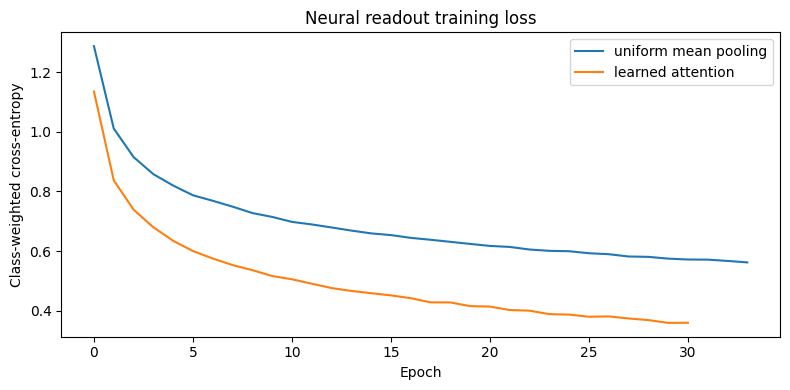

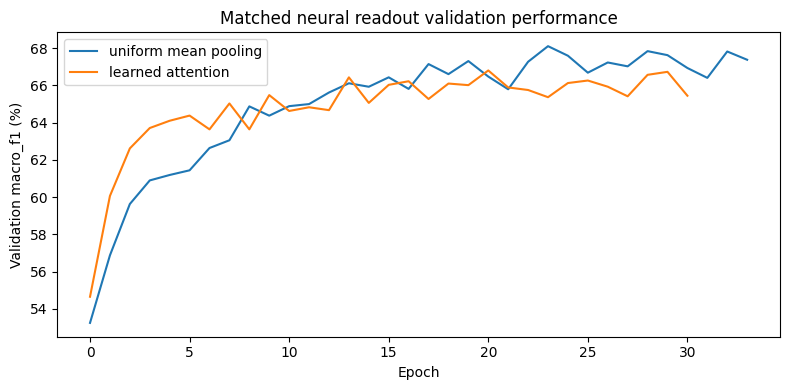

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(mean_history["train_loss"], label="uniform mean pooling")
plt.plot(attention_history["train_loss"], label="learned attention")
plt.xlabel("Epoch")
plt.ylabel("Class-weighted cross-entropy")
plt.title("Neural readout training loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matched_readout_training_loss.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.array(mean_history[f"valid_{VALIDATION_METRIC}"]) * 100, label="uniform mean pooling")
plt.plot(np.array(attention_history[f"valid_{VALIDATION_METRIC}"]) * 100, label="learned attention")
plt.xlabel("Epoch")
plt.ylabel(f"Validation {VALIDATION_METRIC} (%)")
plt.title("Matched neural readout validation performance")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "matched_readout_validation.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Test evaluation

Evaluates the selected checkpoints once on the held-out NSynth test split.

In [18]:
mean_test = evaluate_model(mean_model, mean_test_loader)
attention_test = evaluate_model(attention_model, attention_test_loader)

mean_preds = mean_test["preds"]
attention_preds = attention_test["preds"]

for name, result in [("Uniform neural mean pooling", mean_test),
                     ("Learned temporal attention", attention_test)]:
    print(name)
    print(f"  accuracy:      {result['acc']*100:.2f}%")
    print(f"  macro F1:      {result['macro_f1']*100:.2f}%")
    print(f"  balanced acc:  {result['balanced_acc']*100:.2f}%")

print("\nAttention classification report:")
print(classification_report(y_test, attention_preds, target_names=FAMILY_NAMES))

Uniform neural mean pooling
  accuracy:      69.26%
  macro F1:      68.67%
  balanced acc:  72.00%
Learned temporal attention
  accuracy:      67.55%
  macro F1:      67.12%
  balanced acc:  69.59%

Attention classification report:
              precision    recall  f1-score   support

        bass       0.76      0.61      0.68       843
       brass       0.71      0.72      0.71       269
       flute       0.56      0.69      0.62       180
      guitar       0.54      0.69      0.61       652
    keyboard       0.70      0.70      0.70       766
      mallet       0.48      0.64      0.55       202
       organ       0.97      0.57      0.72       502
        reed       0.61      0.54      0.57       235
      string       0.94      0.93      0.94       306
       vocal       0.48      0.87      0.62       141

    accuracy                           0.68      4096
   macro avg       0.68      0.70      0.67      4096
weighted avg       0.71      0.68      0.68      4096



## 17. Paired statistical tests

Runs the paired McNemar comparisons reported in Results Sections 4.2 and 4.3.

In [19]:

def mcnemar_comparison(
    predictions_a,
    predictions_b,
    labels,
    name_a: str,
    name_b: str,
) -> dict:
    correct_a = np.asarray(predictions_a) == labels
    correct_b = np.asarray(predictions_b) == labels

    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    discordant = b + c

    if discordant == 0:
        corrected_statistic = 0.0
        corrected_p = 1.0
        exact_p = 1.0
    else:
        corrected_statistic = (
            (abs(b - c) - 1) ** 2
        ) / discordant
        corrected_p = float(
            chi2.sf(corrected_statistic, df=1)
        )
        exact_p = float(
            binomtest(
                min(b, c),
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )

    print(f"{name_a} only correct: {b}")
    print(f"{name_b} only correct: {c}")
    print(
        "Continuity-corrected chi-square: "
        f"{corrected_statistic:.4f}"
    )
    print(f"Corrected p-value:             {corrected_p:.3e}")
    print(f"Exact two-sided p-value:       {exact_p:.3e}")

    return {
        "b": b,
        "c": c,
        "discordant": discordant,
        "chi_square_corrected": float(
            corrected_statistic
        ),
        "p_corrected": corrected_p,
        "p_exact": exact_p,
    }


print("RQ1 primary: acoustic features versus ESN states")
rq1_mcnemar = mcnemar_comparison(
    mel_ridge_preds,
    state_ridge_preds,
    y_test,
    "Acoustic Ridge",
    "ESN-state Ridge",
)

print(
    "\nRQ2 primary: uniform versus learned "
    "temporal pooling"
)
rq2_pooling_mcnemar = mcnemar_comparison(
    mean_preds,
    attention_preds,
    y_test,
    "Uniform mean",
    "Attention",
)

print(
    "\nRQ2 supporting comparison: "
    "ESN-state Ridge versus attention"
)
rq2_ridge_mcnemar = mcnemar_comparison(
    state_ridge_preds,
    attention_preds,
    y_test,
    "ESN-state Ridge",
    "Attention",
)


RQ1 primary: acoustic features versus ESN states
Acoustic Ridge only correct: 162
ESN-state Ridge only correct: 980
Continuity-corrected chi-square: 584.4912
Corrected p-value:             3.955e-129
Exact two-sided p-value:       4.404e-143

RQ2 primary: uniform versus learned temporal pooling
Uniform mean only correct: 316
Attention only correct: 246
Continuity-corrected chi-square: 8.4715
Corrected p-value:             3.607e-03
Exact two-sided p-value:       3.570e-03

RQ2 supporting comparison: ESN-state Ridge versus attention
ESN-state Ridge only correct: 336
Attention only correct: 328
Continuity-corrected chi-square: 0.0738
Corrected p-value:             7.859e-01
Exact two-sided p-value:       7.859e-01


## 18. Confusion matrices

Displays the held-out test confusion matrices used in the Results chapter.

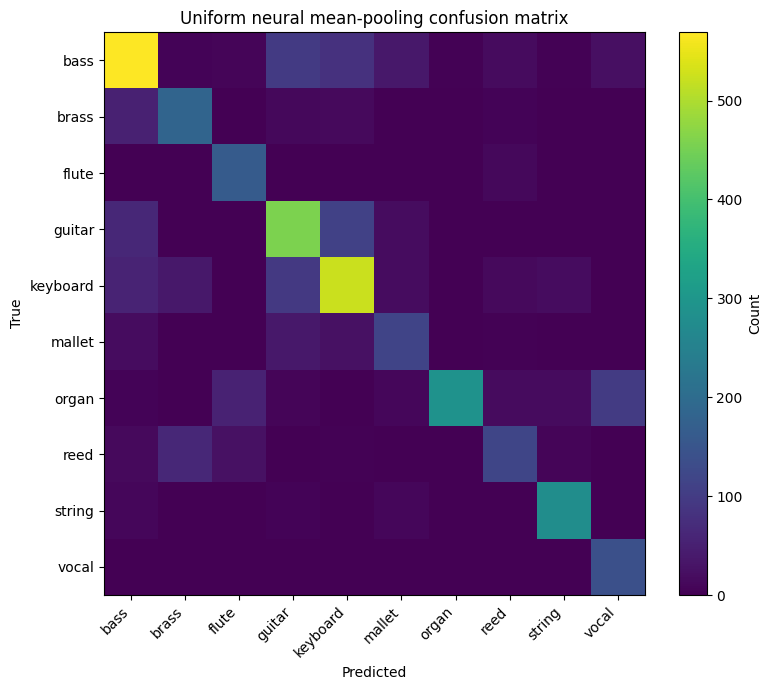

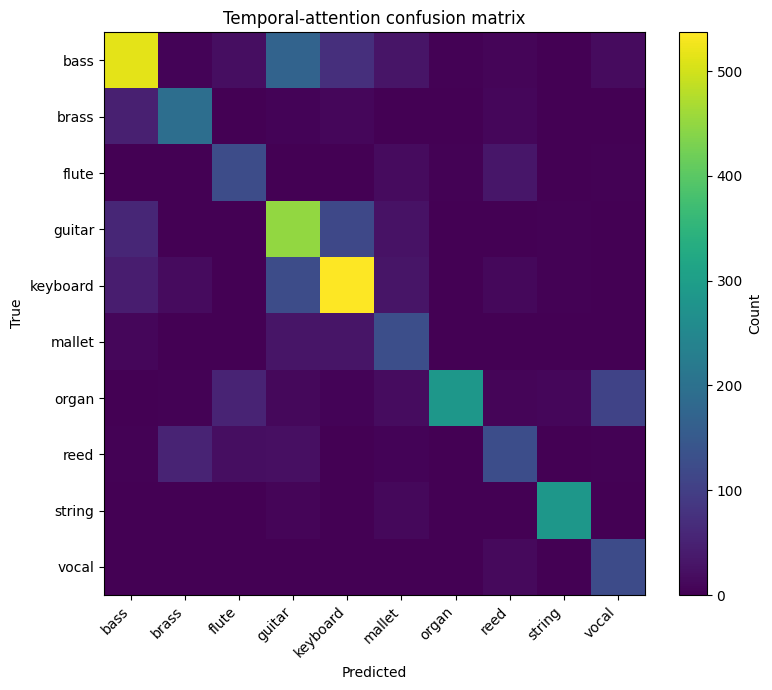

In [20]:
for tag, title, preds in [
    ("mean", "Uniform neural mean-pooling confusion matrix", mean_preds),
    ("attention", "Temporal-attention confusion matrix", attention_preds),
]:
    cm = confusion_matrix(y_test, preds, labels=np.arange(N_CLASSES))
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, aspect="auto")
    plt.xticks(np.arange(N_CLASSES), FAMILY_NAMES, rotation=45, ha="right")
    plt.yticks(np.arange(N_CLASSES), FAMILY_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{tag}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

## 19. RQ3 - temporal attention

Extracts the learned temporal weighting used in Methodology Section 3.4.1 and Results Section 4.4.

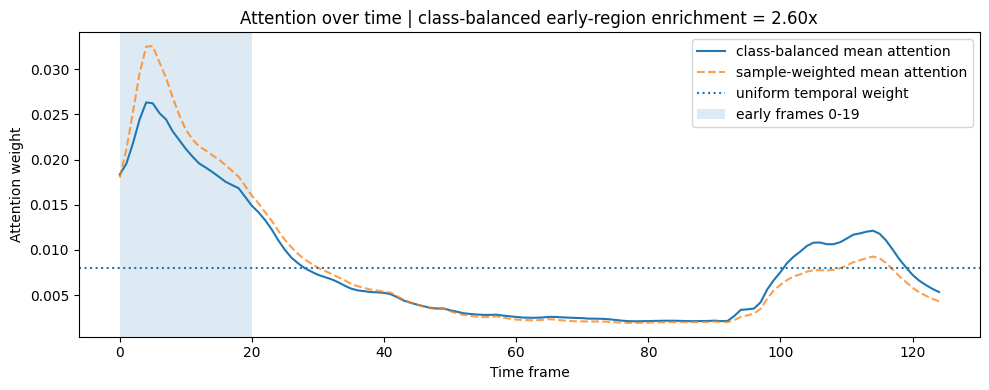

Early-region share of frames:              16.00%
Class-balanced share of attention:         41.59%
Class-balanced attention enrichment:       2.60x
Sample-weighted share of attention:        47.24%
Sample-weighted attention enrichment:      2.95x


In [21]:
@torch.no_grad()
def collect_pooling_weights(model, loader):
    model.eval()
    weights, labels = [], []
    for X, y in loader:
        X = X.to(DEVICE, non_blocking=True)
        _, batch_weights = model(X, return_attention=True)
        weights.append(batch_weights.cpu().numpy())
        labels.append(y.numpy())
    return np.concatenate(weights), np.concatenate(labels)


all_attention, attention_labels = collect_pooling_weights(
    attention_model, attention_test_loader
)

# Calculate one mean profile per family, then average families equally.
# This prevents the unequal NSynth class counts from dominating the headline RQ3 profile.
class_attention_profiles = {}
class_attention_counts = {}
for class_id, name in enumerate(FAMILY_NAMES):
    mask = attention_labels == class_id
    class_attention_counts[name] = int(mask.sum())
    if mask.any():
        class_attention_profiles[class_id] = all_attention[mask].mean(axis=0)

class_balanced_mean_attention = np.mean(
    np.stack(list(class_attention_profiles.values()), axis=0),
    axis=0,
)
sample_weighted_mean_attention = all_attention.mean(axis=0)

uniform_attack_mass = ATTACK_FRAMES / MAX_T

# Primary, class-balanced RQ3 result
attack_mass = float(
    class_balanced_mean_attention[:ATTACK_FRAMES].sum()
    / class_balanced_mean_attention.sum()
)
attack_enrichment = float(attack_mass / uniform_attack_mass)

# Secondary check using every test item equally
sample_weighted_attack_mass = float(
    sample_weighted_mean_attention[:ATTACK_FRAMES].sum()
    / sample_weighted_mean_attention.sum()
)
sample_weighted_attack_enrichment = float(
    sample_weighted_attack_mass / uniform_attack_mass
)

plt.figure(figsize=(10, 4))
plt.plot(
    class_balanced_mean_attention,
    label="class-balanced mean attention",
)
plt.plot(
    sample_weighted_mean_attention,
    linestyle="--",
    alpha=0.75,
    label="sample-weighted mean attention",
)
plt.axhline(
    1.0 / MAX_T,
    linestyle=":",
    label="uniform temporal weight",
)
plt.axvspan(
    0,
    ATTACK_FRAMES,
    alpha=0.15,
    label=f"early frames 0-{ATTACK_FRAMES-1}",
)
plt.xlabel("Time frame")
plt.ylabel("Attention weight")
plt.title(
    "Attention over time | "
    f"class-balanced early-region enrichment = {attack_enrichment:.2f}x"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "attention_over_time.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Early-region share of frames:              {uniform_attack_mass*100:.2f}%")
print(f"Class-balanced share of attention:         {attack_mass*100:.2f}%")
print(f"Class-balanced attention enrichment:       {attack_enrichment:.2f}x")
print(f"Sample-weighted share of attention:        {sample_weighted_attack_mass*100:.2f}%")
print(f"Sample-weighted attention enrichment:      {sample_weighted_attack_enrichment:.2f}x")


## 20. Attention by family

Calculates class-conditional attention profiles for the ten instrument families.

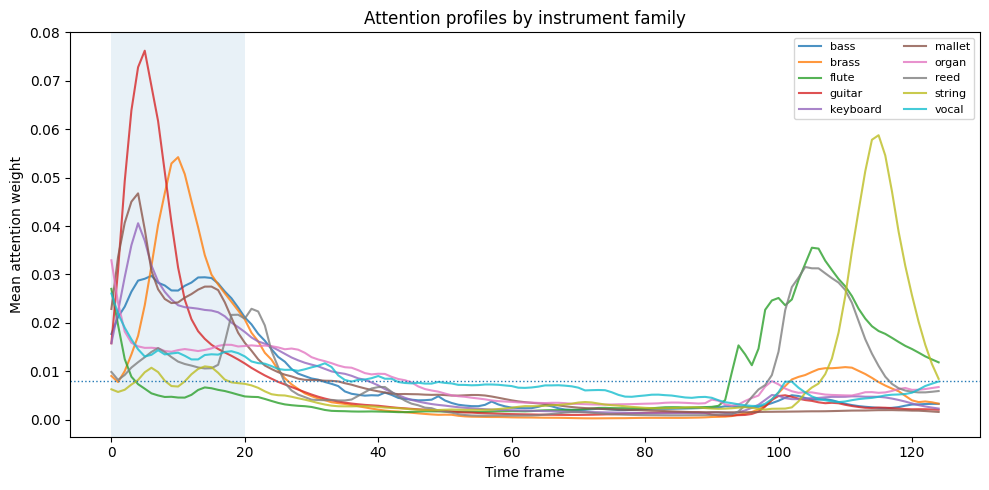

Family          n   early mass   enrichment
bass          843       53.26%        3.33x
brass         269       60.77%        3.80x
flute         180       15.78%        0.99x
guitar        652       71.30%        4.46x
keyboard      766       51.38%        3.21x
mallet        202       58.22%        3.64x
organ         502       32.69%        2.04x
reed          235       25.58%        1.60x
string        306       16.86%        1.05x
vocal         141       30.01%        1.88x


In [22]:
plt.figure(figsize=(10, 5))
class_attention_summary = []

for class_id, name in enumerate(FAMILY_NAMES):
    if class_id not in class_attention_profiles:
        continue

    profile = class_attention_profiles[class_id]
    early_mass = float(profile[:ATTACK_FRAMES].sum() / profile.sum())
    enrichment = float(early_mass / uniform_attack_mass)

    class_attention_summary.append({
        "class_id": int(class_id),
        "family": name,
        "n_test": int(class_attention_counts[name]),
        "early_mass": early_mass,
        "early_enrichment": enrichment,
    })

    plt.plot(profile, label=name, alpha=0.8)

plt.axhline(1.0 / MAX_T, linestyle=":", linewidth=1)
plt.axvspan(0, ATTACK_FRAMES, alpha=0.10)
plt.xlabel("Time frame")
plt.ylabel("Mean attention weight")
plt.title("Attention profiles by instrument family")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "attention_profiles_by_class.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"{'Family':10s} {'n':>6s} {'early mass':>12s} {'enrichment':>12s}")
for row in class_attention_summary:
    print(
        f"{row['family']:10s} "
        f"{row['n_test']:6d} "
        f"{row['early_mass']*100:11.2f}% "
        f"{row['early_enrichment']:11.2f}x"
    )


## 21. Attention enrichment windows

Measures early-region attention enrichment across the predefined temporal windows.

In [23]:
def early_enrichment_curve(
    mean_weights,
    label,
    Ks=(2, 5, 10, 20, 40, 60),
    T=MAX_T,
):
    mean_weights = np.asarray(mean_weights, dtype=np.float64)
    total = mean_weights.sum()
    rows = []

    print(f"\n{label}")
    print(f"{'K':>4} {'seconds':>8} {'weight share':>13} {'enrichment':>11}")
    for K in Ks:
        mass = float(mean_weights[:K].sum() / total)
        enrichment = mass / (K / T)
        seconds = K * HOP_LENGTH / SR
        row = {
            "K": int(K),
            "seconds": float(seconds),
            "weight_mass": mass,
            "enrichment": float(enrichment),
        }
        rows.append(row)
        print(
            f"{K:>4} {seconds:>8.3f} "
            f"{mass*100:>12.2f}% {enrichment:>10.2f}x"
        )
    return rows


# Primary class-balanced curve and secondary sample-weighted confirmation.
enrichment_curve = early_enrichment_curve(
    class_balanced_mean_attention,
    label="Class-balanced attention enrichment",
)
sample_weighted_enrichment_curve = early_enrichment_curve(
    sample_weighted_mean_attention,
    label="Sample-weighted attention enrichment",
)



Class-balanced attention enrichment
   K  seconds  weight share  enrichment
   2    0.064         3.79%       2.37x
   5    0.160        11.04%       2.76x
  10    0.320        23.15%       2.89x
  20    0.640        41.59%       2.60x
  40    1.280        58.54%       1.83x
  60    1.920        65.63%       1.37x

Sample-weighted attention enrichment
   K  seconds  weight share  enrichment
   2    0.064         3.91%       2.44x
   5    0.160        12.64%       3.16x
  10    0.320        27.06%       3.38x
  20    0.640        47.24%       2.95x
  40    1.280        65.72%       2.05x
  60    1.920        72.63%       1.51x


## 22. Five-seed robustness

Repeats the matched RQ2 comparison across seeds 0 to 4 for the final robustness result.

In [24]:

def paired_seed_robustness(
    seeds=ROBUSTNESS_SEEDS,
):
    rows = []

    for seed in seeds:
        if seed == READOUT_SEED:
            mean_result = mean_test
            attention_result = attention_test
            mean_history_local = mean_history
            attention_history_local = attention_history
            print(
                f"seed {seed}: reusing primary matched run"
            )
        else:
            (
                mean_model_local,
                mean_history_local,
                mean_loader_local,
            ) = train_neural_readout(
                "mean",
                seed,
                f"robust_mean_seed_{seed}",
            )
            (
                attention_model_local,
                attention_history_local,
                attention_loader_local,
            ) = train_neural_readout(
                "attention",
                seed,
                f"robust_attention_seed_{seed}",
            )

            mean_result = evaluate_model(
                mean_model_local, mean_loader_local
            )
            attention_result = evaluate_model(
                attention_model_local,
                attention_loader_local,
            )

            del (
                mean_model_local,
                attention_model_local,
                mean_loader_local,
                attention_loader_local,
            )
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        row = {
            "seed": int(seed),
            "mean_acc": float(mean_result["acc"]),
            "mean_macro_f1": float(
                mean_result["macro_f1"]
            ),
            "mean_balanced_acc": float(
                mean_result["balanced_acc"]
            ),
            "attention_acc": float(
                attention_result["acc"]
            ),
            "attention_macro_f1": float(
                attention_result["macro_f1"]
            ),
            "attention_balanced_acc": float(
                attention_result["balanced_acc"]
            ),
            "accuracy_difference": float(
                attention_result["acc"]
                - mean_result["acc"]
            ),
            "macro_f1_difference": float(
                attention_result["macro_f1"]
                - mean_result["macro_f1"]
            ),
            "balanced_accuracy_difference": float(
                attention_result["balanced_acc"]
                - mean_result["balanced_acc"]
            ),
            "mean_best_epoch": int(
                mean_history_local["best_epoch"]
            ),
            "attention_best_epoch": int(
                attention_history_local["best_epoch"]
            ),
            "mean_checkpoint": str(
                mean_history_local["checkpoint"]
            ),
            "attention_checkpoint": str(
                attention_history_local["checkpoint"]
            ),
        }
        rows.append(row)

        print(
            f"seed {seed}: "
            f"mean macro F1="
            f"{row['mean_macro_f1']*100:.2f}% | "
            f"attention macro F1="
            f"{row['attention_macro_f1']*100:.2f}% | "
            f"difference="
            f"{row['macro_f1_difference']*100:+.2f} pp"
        )

    metric_pairs = {
        "accuracy": (
            "mean_acc",
            "attention_acc",
            "accuracy_difference",
        ),
        "macro_f1": (
            "mean_macro_f1",
            "attention_macro_f1",
            "macro_f1_difference",
        ),
        "balanced_accuracy": (
            "mean_balanced_acc",
            "attention_balanced_acc",
            "balanced_accuracy_difference",
        ),
    }

    ddof = 1 if len(rows) > 1 else 0
    summary = {
        "runs": rows,
        "n_seeds": int(len(rows)),
    }

    for metric, (
        mean_key,
        attention_key,
        difference_key,
    ) in metric_pairs.items():
        mean_values = np.array(
            [row[mean_key] for row in rows]
        )
        attention_values = np.array(
            [row[attention_key] for row in rows]
        )
        differences = np.array(
            [row[difference_key] for row in rows]
        )

        summary[f"mean_pooling_{metric}_mean"] = float(
            mean_values.mean()
        )
        summary[f"mean_pooling_{metric}_std"] = float(
            mean_values.std(ddof=ddof)
        )
        summary[f"attention_{metric}_mean"] = float(
            attention_values.mean()
        )
        summary[f"attention_{metric}_std"] = float(
            attention_values.std(ddof=ddof)
        )
        summary[f"{metric}_difference_mean"] = float(
            differences.mean()
        )
        summary[f"{metric}_difference_std"] = float(
            differences.std(ddof=ddof)
        )
        summary[f"{metric}_attention_wins"] = int(
            np.sum(differences > 0)
        )

    print("\nMatched-seed summary")
    for metric in (
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
    ):
        print(
            f"{metric:18s} | attention-minus-mean "
            f"{summary[f'{metric}_difference_mean']*100:+.2f} "
            f"+/- "
            f"{summary[f'{metric}_difference_std']*100:.2f} pp "
            f"| wins "
            f"{summary[f'{metric}_attention_wins']}/"
            f"{len(rows)}"
        )

    return summary


seed_robustness = (
    paired_seed_robustness()
    if RUN_SEED_ROBUSTNESS
    else None
)

if seed_robustness is None:
    print(
        "Seed robustness skipped. "
        "Set FINAL_RUN=True for the definitive run."
    )


seed 0: reusing primary matched run
seed 0: mean macro F1=68.67% | attention macro F1=67.12% | difference=-1.55 pp
mean      readout: 129,418 trainable parameters
robust_mean_seed_1 | epoch 01/60 | loss=1.2924 | valid_macro_f1=53.47% | 60.7s
robust_mean_seed_1 | epoch 02/60 | loss=1.0125 | valid_macro_f1=55.98% | 61.7s
robust_mean_seed_1 | epoch 03/60 | loss=0.9203 | valid_macro_f1=59.38% | 64.3s
robust_mean_seed_1 | epoch 04/60 | loss=0.8641 | valid_macro_f1=59.42% | 67.9s
robust_mean_seed_1 | epoch 05/60 | loss=0.8244 | valid_macro_f1=61.28% | 61.0s
robust_mean_seed_1 | epoch 06/60 | loss=0.7948 | valid_macro_f1=62.56% | 62.0s
robust_mean_seed_1 | epoch 07/60 | loss=0.7703 | valid_macro_f1=63.65% | 60.6s
robust_mean_seed_1 | epoch 08/60 | loss=0.7539 | valid_macro_f1=62.93% | 60.8s
robust_mean_seed_1 | epoch 09/60 | loss=0.7340 | valid_macro_f1=62.73% | 63.2s
robust_mean_seed_1 | epoch 10/60 | loss=0.7168 | valid_macro_f1=63.40% | 62.8s
robust_mean_seed_1 | epoch 11/60 | loss=0.7057 

## 23. RQ3 attention robustness

Aggregates the class-balanced attention profile across the five readout seeds.

attention readout: 129,547 trainable parameters
attention readout: 129,547 trainable parameters
attention readout: 129,547 trainable parameters
attention readout: 129,547 trainable parameters


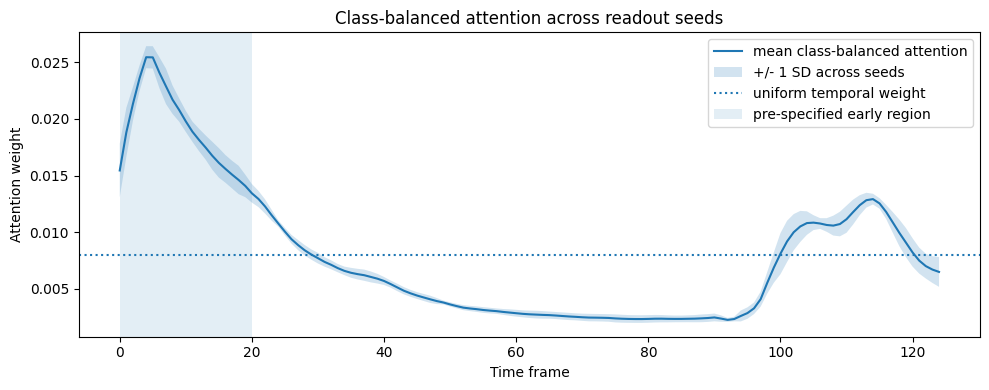

Across-seed early enrichment: 2.41 +/- 0.12x


In [25]:

def class_balanced_profile(
    weights: np.ndarray,
    labels: np.ndarray,
):
    profiles = []
    per_class = {}

    for class_id, family in enumerate(FAMILY_NAMES):
        mask = labels == class_id
        if not mask.any():
            continue
        profile = weights[mask].mean(axis=0)
        profiles.append(profile)
        per_class[family] = profile

    return np.mean(
        np.stack(profiles, axis=0),
        axis=0,
    ), per_class


def load_attention_checkpoint(
    seed: int,
    checkpoint: str,
):
    model = make_temporal_model(
        "attention", seed
    )
    state = torch.load(
        RESULTS_DIR / checkpoint,
        map_location=DEVICE,
    )
    model.load_state_dict(state)
    return model


def attention_seed_analysis(
    seed_summary,
):
    rows = []
    profiles = []

    for run in seed_summary["runs"]:
        seed = int(run["seed"])

        if seed == READOUT_SEED:
            model = attention_model
            loader = attention_test_loader
        else:
            model = load_attention_checkpoint(
                seed,
                run["attention_checkpoint"],
            )
            _, _, loader = make_state_loaders(
                train_state_X,
                valid_state_X,
                test_state_X,
                seed,
            )

        weights, labels = collect_pooling_weights(
            model, loader
        )
        balanced_profile, _ = class_balanced_profile(
            weights, labels
        )
        early_mass = float(
            balanced_profile[:ATTACK_FRAMES].sum()
            / balanced_profile.sum()
        )
        enrichment = float(
            early_mass
            / (ATTACK_FRAMES / MAX_T)
        )

        rows.append(
            {
                "seed": seed,
                "class_balanced_early_mass": early_mass,
                "class_balanced_early_enrichment": enrichment,
            }
        )
        profiles.append(balanced_profile)

        if seed != READOUT_SEED:
            del model, loader
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    profile_array = np.stack(profiles, axis=0)
    enrichment_values = np.array(
        [
            row["class_balanced_early_enrichment"]
            for row in rows
        ]
    )
    mass_values = np.array(
        [
            row["class_balanced_early_mass"]
            for row in rows
        ]
    )
    ddof = 1 if len(rows) > 1 else 0

    summary = {
        "runs": rows,
        "n_seeds": len(rows),
        "early_mass_mean": float(mass_values.mean()),
        "early_mass_std": float(
            mass_values.std(ddof=ddof)
        ),
        "early_enrichment_mean": float(
            enrichment_values.mean()
        ),
        "early_enrichment_std": float(
            enrichment_values.std(ddof=ddof)
        ),
        "profile_mean": profile_array.mean(
            axis=0
        ).tolist(),
        "profile_std": profile_array.std(
            axis=0, ddof=ddof
        ).tolist(),
    }

    mean_profile = np.asarray(
        summary["profile_mean"]
    )
    std_profile = np.asarray(
        summary["profile_std"]
    )
    frames = np.arange(MAX_T)

    plt.figure(figsize=(10, 4))
    plt.plot(
        frames,
        mean_profile,
        label="mean class-balanced attention",
    )
    plt.fill_between(
        frames,
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.20,
        label="+/- 1 SD across seeds",
    )
    plt.axhline(
        1.0 / MAX_T,
        linestyle=":",
        label="uniform temporal weight",
    )
    plt.axvspan(
        0,
        ATTACK_FRAMES,
        alpha=0.12,
        label="pre-specified early region",
    )
    plt.xlabel("Time frame")
    plt.ylabel("Attention weight")
    plt.title(
        "Class-balanced attention across readout seeds"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        RESULTS_DIR
        / "attention_over_time_across_seeds.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print(
        "Across-seed early enrichment: "
        f"{summary['early_enrichment_mean']:.2f} "
        f"+/- "
        f"{summary['early_enrichment_std']:.2f}x"
    )
    return summary


attention_seed_robustness = (
    attention_seed_analysis(seed_robustness)
    if (
        RUN_ATTENTION_SEED_ANALYSIS
        and seed_robustness is not None
    )
    else None
)


## 24. Temporal masking

Runs the readout-side and input-side masking experiments described in Methodology Section 3.4.2.

In [26]:

def make_region_mask(
    region: str,
    K: int = ATTACK_FRAMES,
    T: int = MAX_T,
) -> np.ndarray:
    # True retains a frame; False masks it.
    keep = np.ones(T, dtype=bool)

    if region == "full":
        return keep
    if region == "mask_early":
        keep[:K] = False
        return keep
    if region == "keep_early_only":
        keep[K:] = False
        return keep
    if region == "mask_control":
        # Pre-specified equally sized central control region.
        start = (T - K) // 2
        keep[start:start + K] = False
        return keep

    raise ValueError(f"Unknown region: {region}")


ABLATION_CONDITIONS = (
    "full",
    "mask_early",
    "mask_control",
    "keep_early_only",
)


def evaluate_pooling_pair(
    tag,
    seed,
    Xtr,
    Xva,
    Xte,
    keep_mask=None,
):
    pair = {}

    for pooling in ("mean", "attention"):
        model, history, loader = train_neural_readout(
            pooling=pooling,
            seed=seed,
            tag=f"{tag}_{pooling}_seed_{seed}",
            X_train_path=Xtr,
            X_valid_path=Xva,
            X_test_path=Xte,
            keep_mask=keep_mask,
        )
        result = evaluate_model(model, loader)
        pair[pooling] = {
            "best_validation_score": float(
                history["best_score"]
            ),
            "best_epoch": int(
                history["best_epoch"]
            ),
            "test": {
                key: float(result[key])
                for key in (
                    "acc",
                    "macro_f1",
                    "balanced_acc",
                )
            },
        }

        del model, loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pair


def primary_pair_result():
    return {
        "mean": {
            "best_validation_score": float(
                mean_history["best_score"]
            ),
            "best_epoch": int(
                mean_history["best_epoch"]
            ),
            "test": {
                key: float(mean_test[key])
                for key in (
                    "acc",
                    "macro_f1",
                    "balanced_acc",
                )
            },
        },
        "attention": {
            "best_validation_score": float(
                attention_history["best_score"]
            ),
            "best_epoch": int(
                attention_history["best_epoch"]
            ),
            "test": {
                key: float(attention_test[key])
                for key in (
                    "acc",
                    "macro_f1",
                    "balanced_acc",
                )
            },
        },
    }


def run_readout_ablation(
    conditions=ABLATION_CONDITIONS,
):
    rows = {}

    for condition in conditions:
        if condition == "full":
            rows[condition] = primary_pair_result()
            print(
                "readout/full: reusing primary matched run"
            )
            continue

        keep = make_region_mask(condition)
        rows[condition] = evaluate_pooling_pair(
            tag=f"readout_{condition}",
            seed=ABLATION_SEED,
            Xtr=train_state_X,
            Xva=valid_state_X,
            Xte=test_state_X,
            keep_mask=keep,
        )

    return rows


def rebuild_masked_feature_sequence(
    feature_sequence: np.ndarray,
    keep: np.ndarray,
) -> np.ndarray:
    # Cached static features already have the same fixed 125-frame
    # length used by the full pipeline.
    static = np.asarray(
        feature_sequence[:, :N_MELS],
        dtype=np.float32,
    ).copy()

    # Mean replacement is performed in the raw log-mel feature space.
    static[~keep] = feature_scaler.mean_[:N_MELS]

    if not USE_DELTAS:
        return static

    d1 = librosa.feature.delta(
        static.T, order=1
    ).T
    d2 = librosa.feature.delta(
        static.T, order=2
    ).T
    return np.concatenate(
        [static, d1, d2],
        axis=1,
    ).astype(np.float32)


def masked_condition_tag(
    condition: str,
    keep: np.ndarray,
) -> str:
    return stable_hash(
        {
            "state_tag": STATE_TAG,
            "condition": condition,
            "keep": keep.tolist(),
            "masking": (
                "static_training_mean_then_"
                "recompute_deltas_same_125_frames_v2"
            ),
            "condition_specific_state_scaler": True,
        }
    )


def fit_or_load_masked_state_scaler(
    condition: str,
    keep: np.ndarray,
):
    tag = masked_condition_tag(condition, keep)
    out_dir = STATE_CACHE_DIR / f"input_mask_{tag}"
    out_dir.mkdir(parents=True, exist_ok=True)
    scaler_path = out_dir / "state_scaler.joblib"

    if (
        scaler_path.exists()
        and not FORCE_REBUILD_STATE_CACHE
    ):
        return joblib.load(scaler_path), out_dir

    print(
        f"Fitting condition-specific state scaler: "
        f"{condition}"
    )
    X_mel = np.load(train_mel_X, mmap_mode="r")
    rng = np.random.default_rng(SEED)
    n = min(SCALER_N_EXAMPLES, len(X_mel))
    indices = rng.choice(
        len(X_mel), size=n, replace=False
    )

    local_scaler = StandardScaler()
    for j, i in enumerate(indices):
        rebuilt = rebuild_masked_feature_sequence(
            np.asarray(
                X_mel[i], dtype=np.float32
            ),
            keep,
        )
        states = run_reservoir_on_feature(
            rebuilt,
            feature_scaler,
            reservoir,
        )
        local_scaler.partial_fit(states)

        if (
            (j + 1) % 500 == 0
            or j + 1 == len(indices)
        ):
            print(
                f"  {condition} scaler "
                f"{j+1:,}/{len(indices):,}"
            )

    joblib.dump(local_scaler, scaler_path)
    del X_mel
    gc.collect()
    return local_scaler, out_dir


def cache_masked_input_states(
    split_name,
    mel_X_path,
    keep,
    condition,
    local_state_scaler,
    out_dir,
):
    out_path = out_dir / f"X_states_{split_name}.npy"
    X_mel = np.load(mel_X_path, mmap_mode="r")
    expected = (
        len(X_mel),
        MAX_T,
        RESERVOIR_UNITS,
    )

    if (
        npy_cache_valid(
            out_path,
            expected,
            STATE_CACHE_DTYPE,
        )
        and not FORCE_REBUILD_STATE_CACHE
    ):
        del X_mel
        return out_path

    X_state = np.lib.format.open_memmap(
        out_path,
        mode="w+",
        dtype=STATE_CACHE_DTYPE,
        shape=expected,
    )

    started = time.time()
    for i in range(len(X_mel)):
        rebuilt = rebuild_masked_feature_sequence(
            np.asarray(
                X_mel[i], dtype=np.float32
            ),
            keep,
        )
        states = run_reservoir_on_feature(
            rebuilt,
            feature_scaler,
            reservoir,
        )
        states = local_state_scaler.transform(states)
        X_state[i] = states.astype(
            STATE_CACHE_DTYPE,
            copy=False,
        )

        if (
            (i + 1) % 5_000 == 0
            or i + 1 == len(X_mel)
        ):
            X_state.flush()
            print(
                f"{condition}/{split_name}: "
                f"{i+1:,}/{len(X_mel):,} | "
                f"{time.time()-started:.1f}s"
            )

    X_state.flush()
    del X_state, X_mel
    gc.collect()
    return out_path


def remove_masked_state_caches(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            path.unlink()


def run_input_ablation(
    conditions=ABLATION_CONDITIONS,
):
    rows = {}

    for condition in conditions:
        if condition == "full":
            rows[condition] = primary_pair_result()
            print(
                "input/full: reusing primary matched run"
            )
            continue

        keep = make_region_mask(condition)
        local_scaler, out_dir = (
            fit_or_load_masked_state_scaler(
                condition, keep
            )
        )

        train_path = cache_masked_input_states(
            "train",
            train_mel_X,
            keep,
            condition,
            local_scaler,
            out_dir,
        )
        valid_path = cache_masked_input_states(
            "valid",
            valid_mel_X,
            keep,
            condition,
            local_scaler,
            out_dir,
        )
        test_path = cache_masked_input_states(
            "test",
            test_mel_X,
            keep,
            condition,
            local_scaler,
            out_dir,
        )

        rows[condition] = evaluate_pooling_pair(
            tag=f"input_{condition}",
            seed=ABLATION_SEED,
            Xtr=train_path,
            Xva=valid_path,
            Xte=test_path,
            keep_mask=None,
        )

        if not KEEP_MASKED_STATE_CACHES:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            remove_masked_state_caches(
                (train_path, valid_path, test_path)
            )
            print(
                "Deleted temporary masked state arrays "
                f"for {condition}"
            )

    return rows


readout_ablation = (
    run_readout_ablation()
    if RUN_READOUT_ABLATION
    else None
)
input_ablation = (
    run_input_ablation()
    if RUN_INPUT_ABLATION
    else None
)

print(
    f"Readout-side ablation run: "
    f"{readout_ablation is not None}"
)
print(
    f"Input-side ablation run:   "
    f"{input_ablation is not None}"
)


readout/full: reusing primary matched run
mean      readout: 129,418 trainable parameters
readout_mask_early_mean_seed_0 | epoch 01/60 | loss=1.3121 | valid_macro_f1=52.29% | 62.9s
readout_mask_early_mean_seed_0 | epoch 02/60 | loss=1.0336 | valid_macro_f1=55.63% | 62.7s
readout_mask_early_mean_seed_0 | epoch 03/60 | loss=0.9408 | valid_macro_f1=58.36% | 62.8s
readout_mask_early_mean_seed_0 | epoch 04/60 | loss=0.8829 | valid_macro_f1=59.40% | 65.1s
readout_mask_early_mean_seed_0 | epoch 05/60 | loss=0.8461 | valid_macro_f1=59.80% | 61.6s
readout_mask_early_mean_seed_0 | epoch 06/60 | loss=0.8119 | valid_macro_f1=60.23% | 62.6s
readout_mask_early_mean_seed_0 | epoch 07/60 | loss=0.7925 | valid_macro_f1=61.69% | 62.3s
readout_mask_early_mean_seed_0 | epoch 08/60 | loss=0.7739 | valid_macro_f1=61.09% | 61.9s
readout_mask_early_mean_seed_0 | epoch 09/60 | loss=0.7537 | valid_macro_f1=63.65% | 68.6s
readout_mask_early_mean_seed_0 | epoch 10/60 | loss=0.7381 | valid_macro_f1=63.68% | 60.5s


## 25. Save definitive results

Writes the result summary, predictions, attention profiles and run metadata used by Notebooks 03 to 05.

In [27]:

def strip_predictions(result):
    return {
        key: value
        for key, value in result.items()
        if key != "preds"
    }


results = {
    "config": {
        "run_tag": RUN_TAG,
        "selection_manifest": str(
            SELECTION_MANIFEST_PATH.relative_to(PROJECT_ROOT)
        ),
        "seed": SEED,
        "readout_seed": READOUT_SEED,
        "feature_cfg": FEATURE_CFG,
        "reservoir_cfg": RESERVOIR_CFG,
        "feature_tag": FEATURE_TAG,
        "scaler_tag": SCALER_TAG,
        "state_tag": STATE_TAG,
        "n_train": int(len(y_train)),
        "n_valid": int(len(y_valid)),
        "n_test": int(len(y_test)),
        "ridge_train_n": (
            None
            if RIDGE_TRAIN_N is None
            else int(RIDGE_TRAIN_N)
        ),
        "ridge_alphas": RIDGE_ALPHAS,
        "ridge_class_weight": RIDGE_CLASS_WEIGHT,
        "ridge_solver": RIDGE_SOLVER,
        "ridge_tol": RIDGE_TOL,
        "ridge_max_iter": RIDGE_MAX_ITER,
        "validation_metric": VALIDATION_METRIC,
        "neural_class_weight": "balanced",
        "batch_size": int(BATCH_SIZE),
        "hidden_dim": int(HIDDEN_DIM),
        "dropout": float(DROPOUT),
        "learning_rate": float(LR),
        "weight_decay": float(WEIGHT_DECAY),
        "max_epochs": int(N_EPOCHS),
        "patience": int(PATIENCE),
        "state_cache_dtype": str(
            np.dtype(STATE_CACHE_DTYPE)
        ),
        "final_run": bool(FINAL_RUN),
        "run_seed_robustness": bool(
            RUN_SEED_ROBUSTNESS
        ),
        "run_attention_seed_analysis": bool(
            RUN_ATTENTION_SEED_ANALYSIS
        ),
        "run_readout_ablation": bool(
            RUN_READOUT_ABLATION
        ),
        "run_input_ablation": bool(
            RUN_INPUT_ABLATION
        ),
        "attack_frames": int(ATTACK_FRAMES),
        "attack_seconds": float(
            ATTACK_FRAMES * HOP_LENGTH / SR
        ),
    },
    "rq1": {
        "acoustic_ridge": strip_predictions(
            mel_ridge
        ),
        "esn_state_ridge": strip_predictions(
            state_ridge
        ),
        "mcnemar": rq1_mcnemar,
    },
    "rq2": {
        "uniform_mean": {
            "history": mean_history,
            "test": {
                key: float(mean_test[key])
                for key in (
                    "acc",
                    "macro_f1",
                    "balanced_acc",
                )
            },
        },
        "attention": {
            "history": attention_history,
            "test": {
                key: float(attention_test[key])
                for key in (
                    "acc",
                    "macro_f1",
                    "balanced_acc",
                )
            },
        },
        "mcnemar_vs_uniform": (
            rq2_pooling_mcnemar
        ),
        "mcnemar_vs_ridge": (
            rq2_ridge_mcnemar
        ),
        "seed_robustness": seed_robustness,
    },
    "rq3": {
        "primary_profile": "seed_0_class_balanced",
        "class_balanced_early_mass": float(
            attack_mass
        ),
        "class_balanced_uniform_early_mass": float(
            uniform_attack_mass
        ),
        "class_balanced_early_enrichment": float(
            attack_enrichment
        ),
        "sample_weighted_early_mass": float(
            sample_weighted_attack_mass
        ),
        "sample_weighted_early_enrichment": float(
            sample_weighted_attack_enrichment
        ),
        "class_attention_summary": (
            class_attention_summary
        ),
        "class_balanced_enrichment_curve": (
            enrichment_curve
        ),
        "sample_weighted_enrichment_curve": (
            sample_weighted_enrichment_curve
        ),
        "attention_seed_robustness": (
            attention_seed_robustness
        ),
        "readout_ablation": readout_ablation,
        "input_ablation": input_ablation,
    },
}

summary_path = (
    RESULTS_DIR / "results_summary_final.json"
)
with open(summary_path, "w") as f:
    json.dump(results, f, indent=2)

with open(
    RESULTS_DIR / "run_config.json",
    "w",
) as f:
    json.dump(RUN_CFG, f, indent=2)

with open(
    RESULTS_DIR / "selection_manifest_copy.json",
    "w",
) as f:
    json.dump(SELECTION_MANIFEST, f, indent=2)

np.save(
    RESULTS_DIR / "test_labels.npy",
    y_test,
)
np.save(
    RESULTS_DIR
    / "test_predictions_acoustic_ridge.npy",
    mel_ridge_preds,
)
np.save(
    RESULTS_DIR
    / "test_predictions_esn_ridge.npy",
    state_ridge_preds,
)
np.save(
    RESULTS_DIR
    / "test_predictions_neural_mean.npy",
    mean_preds,
)
np.save(
    RESULTS_DIR
    / "test_predictions_attention.npy",
    attention_preds,
)
np.save(
    RESULTS_DIR / "test_attention_weights.npy",
    all_attention,
)
np.save(
    RESULTS_DIR
    / "attention_profile_class_balanced.npy",
    class_balanced_mean_attention,
)
np.save(
    RESULTS_DIR
    / "attention_profile_sample_weighted.npy",
    sample_weighted_mean_attention,
)
np.save(
    RESULTS_DIR
    / "attention_profiles_by_class.npy",
    np.stack(
        [
            class_attention_profiles[class_id]
            for class_id in sorted(
                class_attention_profiles
            )
        ],
        axis=0,
    ),
)

print(f"Saved summary: {summary_path}")
print(f"Saved arrays:  {RESULTS_DIR}")


Saved summary: /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b/results_summary_final.json
Saved arrays:  /home/olliechandler/ESN-NSYNTH/results_final/run_35d8eed08b


## 26. Completion checks

Confirms that the definitive RQ1 to RQ3 artefacts were written successfully.

In [28]:

comparison_rows = [
    (
        "Acoustic features + balanced Ridge",
        mel_ridge["test"],
    ),
    (
        "ESN states + balanced Ridge",
        state_ridge["test"],
    ),
    (
        "ESN states + neural mean pooling",
        mean_test,
    ),
    (
        "ESN states + neural attention",
        attention_test,
    ),
]

print(
    f"{'System':42s} "
    f"{'Accuracy':>10s} "
    f"{'Macro F1':>10s} "
    f"{'Balanced':>10s}"
)
for name, metrics in comparison_rows:
    print(
        f"{name:42s} "
        f"{metrics['acc']*100:9.2f}% "
        f"{metrics['macro_f1']*100:9.2f}% "
        f"{metrics['balanced_acc']*100:9.2f}%"
    )

if seed_robustness is not None:
    print("\nFive-seed matched neural comparison")
    for metric in (
        "accuracy",
        "macro_f1",
        "balanced_accuracy",
    ):
        print(
            f"{metric:18s}: "
            f"{seed_robustness[f'{metric}_difference_mean']*100:+.2f} "
            f"+/- "
            f"{seed_robustness[f'{metric}_difference_std']*100:.2f} pp "
            f"(attention wins "
            f"{seed_robustness[f'{metric}_attention_wins']}/"
            f"{seed_robustness['n_seeds']})"
        )

checks = {
    "locked_selection_loaded": (
        SELECTION_MANIFEST.get(
            "selection_status"
        )
        == "locked"
    ),
    "feature_configuration_matches": (
        SELECTION_MANIFEST["feature_cfg"]
        == FEATURE_CFG
    ),
    "reservoir_configuration_matches": (
        SELECTION_MANIFEST["reservoir_cfg"]
        == RESERVOIR_CFG
    ),
    "seed_robustness_completed": (
        seed_robustness is not None
    ),
    "attention_seed_analysis_completed": (
        attention_seed_robustness is not None
    ),
    "readout_ablation_completed": (
        readout_ablation is not None
    ),
    "input_ablation_completed": (
        input_ablation is not None
    ),
    "summary_saved": summary_path.exists(),
    "acoustic_ridge_not_on_grid_boundary": (
        mel_ridge["alpha"]
        not in (
            min(RIDGE_ALPHAS),
            max(RIDGE_ALPHAS),
        )
    ),
    "state_ridge_not_on_grid_boundary": (
        state_ridge["alpha"]
        not in (
            min(RIDGE_ALPHAS),
            max(RIDGE_ALPHAS),
        )
    ),
}

print("\nFinal completion checks")
for name, complete in checks.items():
    print(f"  {name:42s}: {complete}")

if FINAL_RUN and not all(checks.values()):
    failed = [
        name
        for name, complete in checks.items()
        if not complete
    ]
    raise RuntimeError(
        "The definitive final run is incomplete. "
        f"Failed checks: {failed}"
    )

with open(
    PROJECT_ROOT / "results_final" / "latest_run.json",
    "w",
) as f:
    json.dump({"run_tag": RUN_TAG}, f, indent=2)

print(f"Updated latest-run pointer: {RUN_TAG}")

print(
    "\nRun complete. Save this notebook "
    "with all outputs."
)


System                                       Accuracy   Macro F1   Balanced
Acoustic features + balanced Ridge             47.78%     45.79%     51.84%
ESN states + balanced Ridge                    67.75%     66.65%     70.35%
ESN states + neural mean pooling               69.26%     68.67%     72.00%
ESN states + neural attention                  67.55%     67.12%     69.59%

Five-seed matched neural comparison
accuracy          : -1.70 +/- 1.18 pp (attention wins 1/5)
macro_f1          : -1.78 +/- 1.10 pp (attention wins 0/5)
balanced_accuracy : -2.15 +/- 1.05 pp (attention wins 0/5)

Final completion checks
  locked_selection_loaded                   : True
  feature_configuration_matches             : True
  reservoir_configuration_matches           : True
  seed_robustness_completed                 : True
  attention_seed_analysis_completed         : True
  readout_ablation_completed                : True
  input_ablation_completed                  : True
  summary_saved         